In [130]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Task 1

In [131]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

# Parameters
n_states = len(P)
n_sims = 1000
states = np.arange(n_states)

# Array to store results
iters = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)


local_reaccurance_count = 0
for i in range(n_sims):
    # Inital parameters
    iter = 0
    curr_state = 0
    local_reaccurance = 0

    # Transition to states until death
    while True:
        iter += 1 
        new_state = rng.choice(states, p=P[curr_state])
        
        # If state is the last state (death) then stop
        if new_state == (n_states-1):
            iters[i] = iter-1
            break

        if new_state == 1:
            local_reaccurance = 1
        
        # Update current state
        curr_state = new_state

    local_reaccurance_count += local_reaccurance


In [132]:
print(f"Propertion of women where the cancer reaccur locally: {local_reaccurance_count / n_sims}")

Propertion of women where the cancer reaccur locally: 0.573


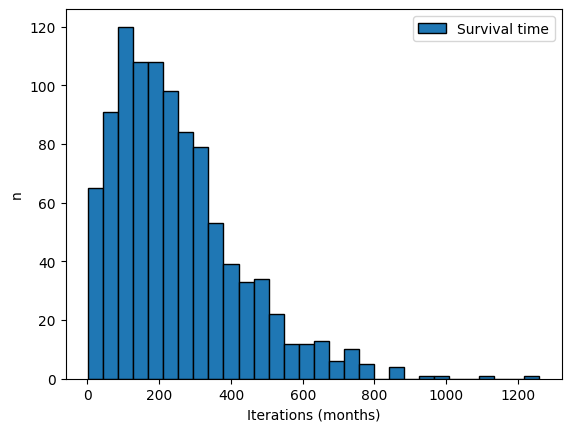

In [133]:
plt.hist(iters,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

# Task 2

In [134]:
# simulate
sims = np.zeros(n_sims, dtype=np.int64)
states = np.arange(n_states)
rng = np.random.default_rng(30)

T = 120

for i in range(n_sims):
    curr_state = 0

    for t in range(T):
        new_state = rng.choice(states, p=P[curr_state])
        curr_state = new_state
    
    sims[i] = curr_state

# Theoretical distr
p0 = np.array([1,0,0,0,0])
pt = p0@np.linalg.matrix_power(P,T)

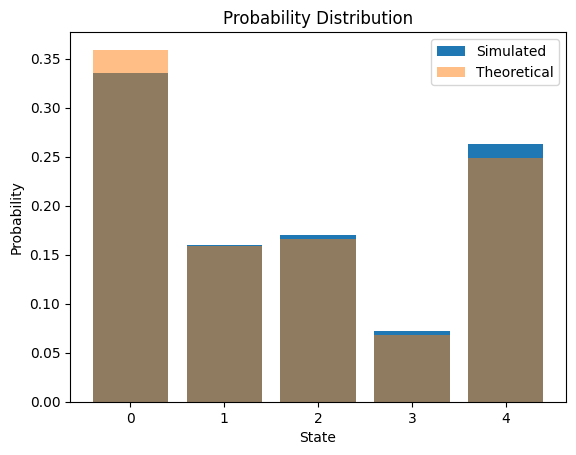

In [135]:
bin_count = np.bincount(sims, minlength=5)
plt.bar(states,bin_count / len(sims), label="Simulated")
plt.bar(states, pt, label="Theoretical", alpha=0.5)
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("Probability Distribution")
plt.xticks(states)
plt.legend()
plt.show()

$\chi^2$-test

In [136]:
T_val, p_val = ss.chisquare(bin_count,1000*pt)
print(T_val,p_val)

2.8584402117411214 0.5817876012777994


# Task 3

In [137]:
pi = np.array([1,0,0,0])
Ps = P[:-1,:-1]
ps = P[:-1,-1]
T = 120

def p_life(t):
    return  pi @ np.linalg.matrix_power(Ps,t) @ ps

E = pi @ np.linalg.inv((np.eye(4) - Ps)) @ np.ones(4)

theoretical_density = np.array([p_life(t) for t in range(int(np.max(iters)))])

In [138]:
print(f"Theoretical mean: {E}, Observed mean {np.mean(iters)}")

Theoretical mean: 262.3716153127931, Observed mean 250.681


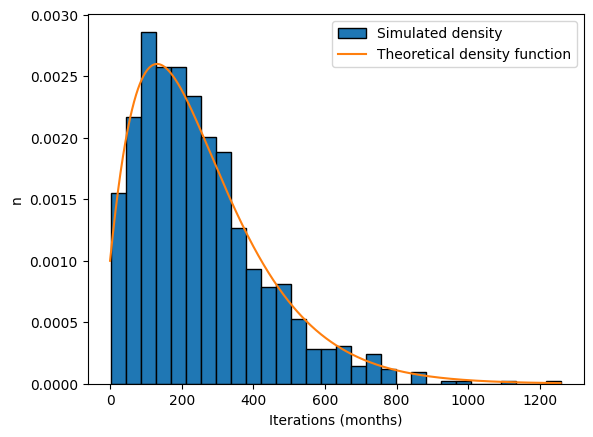

In [140]:
plt.hist(iters,bins=30,density=True, edgecolor="black", label="Simulated density")
plt.plot(np.arange(1259),theoretical_density, label="Theoretical density function" )
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

# Task 4

In [141]:
rng = np.random.default_rng(30)

count= 0
survival_times = []
while count < 1000:
    # Inital parameters
    has_reappeared = 0
    curr_state = 0
    died = 0

    # Simulate first 12 iterations
    for iter in range(12):
        new_state = rng.choice(states, p=P[curr_state])

        if new_state in [1,2,3]:
            has_reappeared = 1
        
        if new_state == (n_states-1):
            died = 1
            break
        
        curr_state = new_state
    
    if (has_reappeared == 0) or (died == 1):
        continue

    # Transition to states until death
    iter = 12
    while True:
        iter += 1
        new_state = rng.choice(states, p=P[curr_state])
        
        # If state is the last state (death) then stop
        if new_state == (n_states-1):
            break
        
        # Update current state
        curr_state = new_state
    
    count += 1
    survival_times.append(iter-1)


In [142]:
np.mean(survival_times)

np.float64(168.974)

# Task 5

Without control variates

In [151]:
rng = np.random.default_rng(30)

fraction = []
mean_lifetime = []
for iter in range(100):
    count = 0
    mean = 0
    for w in range(200):
        # Inital parameters
        curr_state = 0
        iter = 0 

        while True:
            iter += 1
            new_state = rng.choice(states, p=P[curr_state])
            
            if new_state == (n_states-1):
                mean += (iter-1)/200
                break

            curr_state = new_state
        
        if (iter-1) <= 350:
            count += 1
        
    
    mean_lifetime.append(mean)
        
    fraction.append(count/200)


In [146]:
np.mean(fraction), np.var(fraction)

(np.float64(0.74025), np.float64(0.001062187500000001))

With control varaites (true mean from task 2)

In [153]:
np.shape(fraction),np.shape(mean_lifetime)

((100,), (100,))

In [159]:
c = -np.cov(fraction, mean_lifetime)[0,1] / np.var(mean_lifetime)
Y = np.array(fraction) + c*(np.array(mean_lifetime) - E)

In [162]:
np.mean(Y), np.var(Y)

(np.float64(0.7381040471872119), np.float64(0.0003479476477517136))

In [164]:
print(f"Reduction of varaince: {np.var(Y)-np.var(fraction)}")

Reduction of varaince: -0.0007142398522482875


# Task 6